In [ ]:
!pip install prophet shap folium xgboost plotly statsmodels -q

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("GlobalWeatherRepository.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())

Rows: 127,451
Columns: 41

Column Names:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [10]:
print("First 5 rows:")
df.head()

First 5 rows:


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
df.isnull().sum()

In [35]:
# Convert last_updated to a proper datetime format
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Extract useful time components
df["year"]      = df["last_updated"].dt.year
df["month"]     = df["last_updated"].dt.month
df["day"]       = df["last_updated"].dt.day
df["hour"]      = df["last_updated"].dt.hour
df["dayofweek"] = df["last_updated"].dt.dayofweek

# Create season column
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter",  2: "Winter",
    3:  "Spring", 4: "Spring",  5: "Spring",
    6:  "Summer", 7: "Summer",  8: "Summer",
    9:  "Autumn", 10: "Autumn", 11: "Autumn"
})

print(" Date columns created!")
print(df[["last_updated", "year", "month", "day", "hour", "season"]].head())

 Date columns created!
         last_updated  year  month  day  hour  season
0 2024-05-16 13:15:00  2024      5   16    13  Spring
1 2024-05-16 10:45:00  2024      5   16    10  Spring
2 2024-05-16 09:45:00  2024      5   16     9  Spring
3 2024-05-16 10:45:00  2024      5   16    10  Spring
4 2024-05-16 09:45:00  2024      5   16     9  Spring


In [12]:

cols_to_check = [
    "temperature_celsius", "humidity", "wind_kph",
    "pressure_mb", "precip_mm", "uv_index", "air_quality_PM2.5"
]

for col in cols_to_check:
    print(f"{col:<35} Min: {df[col].min():.2f}  Max: {df[col].max():.2f}")

temperature_celsius                 Min: -29.80  Max: 49.20
humidity                            Min: 2.00  Max: 100.00
wind_kph                            Min: 3.60  Max: 2963.20
pressure_mb                         Min: 947.00  Max: 3006.00
precip_mm                           Min: 0.00  Max: 42.24
uv_index                            Min: 0.00  Max: 16.30
air_quality_PM2.5                   Min: 0.17  Max: 1614.10


2963 — fastest wind ever recorded on Earth is about 400kmph
3006 — normal atmospheric pressure is 980-1030 mb
1614 — hazardous levels are around 250, so 1614 is clearly a data error

In [13]:
cols_to_fix = [
    "temperature_celsius", "wind_kph", "pressure_mb",
    "uv_index", "air_quality_PM2.5"
]

for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

for col in cols_to_fix:
    print(f"{col:<35} Min: {df[col].min():.2f}  Max: {df[col].max():.2f}")

temperature_celsius                 Min: -1.50  Max: 45.70
wind_kph                            Min: 3.60  Max: 34.85
pressure_mb                         Min: 998.00  Max: 1030.00
uv_index                            Min: 0.00  Max: 14.85
air_quality_PM2.5                   Min: 0.17  Max: 59.58


In [14]:

print("Unique values per column:")
for col in df.select_dtypes(include=[np.number]).columns:
    unique = df[col].nunique()
    if unique <= 5:
        print(f"{col:<35} Unique values: {unique}")


print(f"\nvisibility_km unique values: {df['visibility_km'].nunique()}")
print(f"visibility_km value counts:\n{df['visibility_km'].value_counts()}")

Unique values per column:
year                                Unique values: 3

visibility_km unique values: 71
visibility_km value counts:
visibility_km
10.0    100216
9.0       5202
8.0       4628
7.0       2780
6.0       2449
         ...  
32.0        17
18.0         8
9.5          2
5.5          1
6.5          1
Name: count, Length: 71, dtype: int64


In [15]:
# Dropping the duplicates
cols_to_drop = [
    "temperature_fahrenheit",  # duplicate of celsius
    "feels_like_fahrenheit",   # duplicate of celsius version
    "wind_mph",                # duplicate of wind_kph
    "gust_mph",                # duplicate of gust_kph
    "pressure_in",             # duplicate of pressure_mb
    "precip_in",               # duplicate of precip_mm
    "visibility_miles",        # duplicate of visibility_km
    "last_updated_epoch",      # duplicate of last_updated
]

df.drop(columns=cols_to_drop, inplace=True)

print(f" {len(cols_to_drop)} duplicate columns")
print(f"Dataset now has {df.shape[1]} columns")

 8 duplicate columns
Dataset now has 39 columns


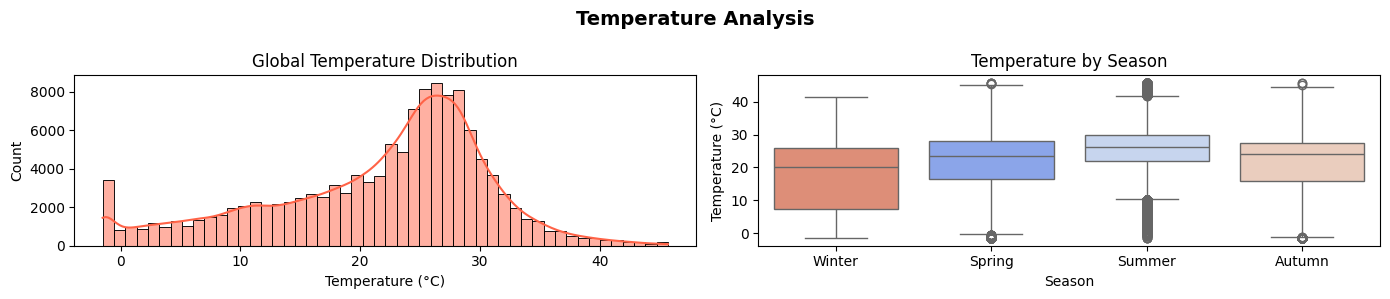

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))


sns.histplot(df["temperature_celsius"], bins=50,
             kde=True, color="tomato", ax=axes[0])
axes[0].set_title("Global Temperature Distribution")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Count")


sns.boxplot(data=df, x="season", y="temperature_celsius",
            order=["Winter", "Spring", "Summer", "Autumn"],
            hue="season", palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].set_title("Temperature by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Temperature (°C)")

plt.suptitle("Temperature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

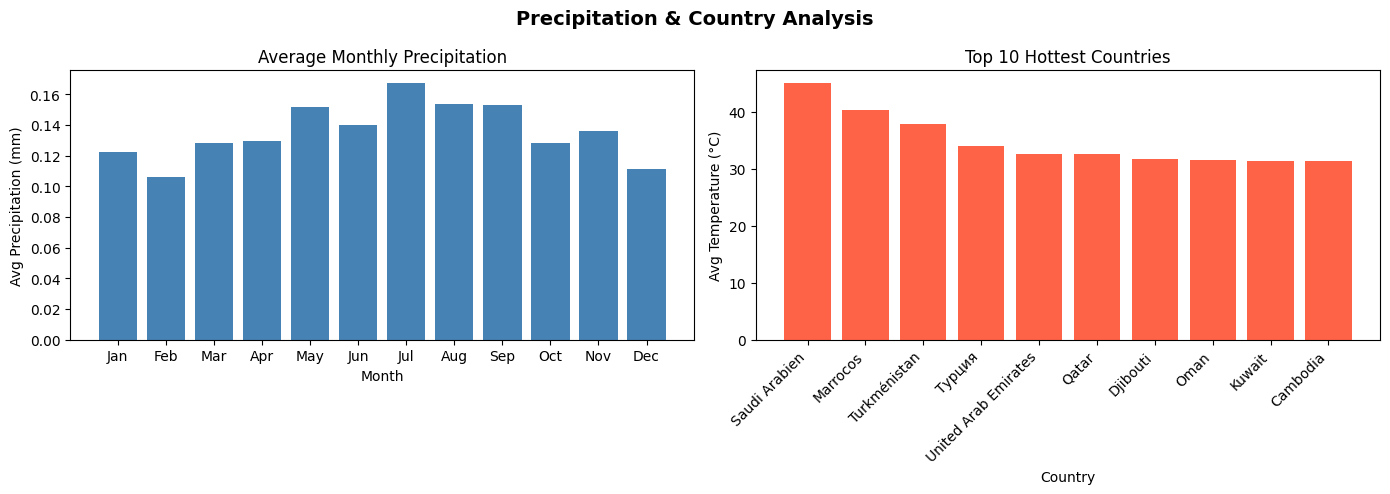

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_precip = df.groupby("month")["precip_mm"].mean()
axes[0].bar(monthly_precip.index, monthly_precip.values, color="steelblue")
axes[0].set_title("Average Monthly Precipitation")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Precipitation (mm)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])

# Top 10 hottest countries
top_countries = (df.groupby("country")["temperature_celsius"]
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))
axes[1].bar(top_countries.index, top_countries.values, color="tomato")
axes[1].set_title("Top 10 Hottest Countries")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Avg Temperature (°C)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.suptitle("Precipitation & Country Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

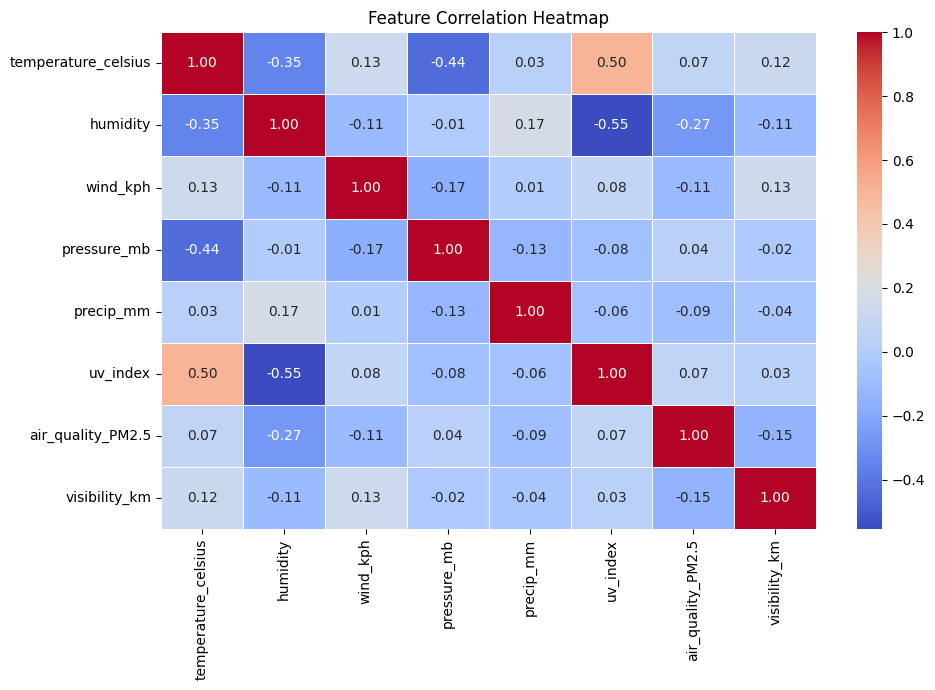

In [18]:
corr_cols = [
    "temperature_celsius", "humidity", "wind_kph",
    "pressure_mb", "precip_mm", "uv_index",
    "air_quality_PM2.5", "visibility_km"
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

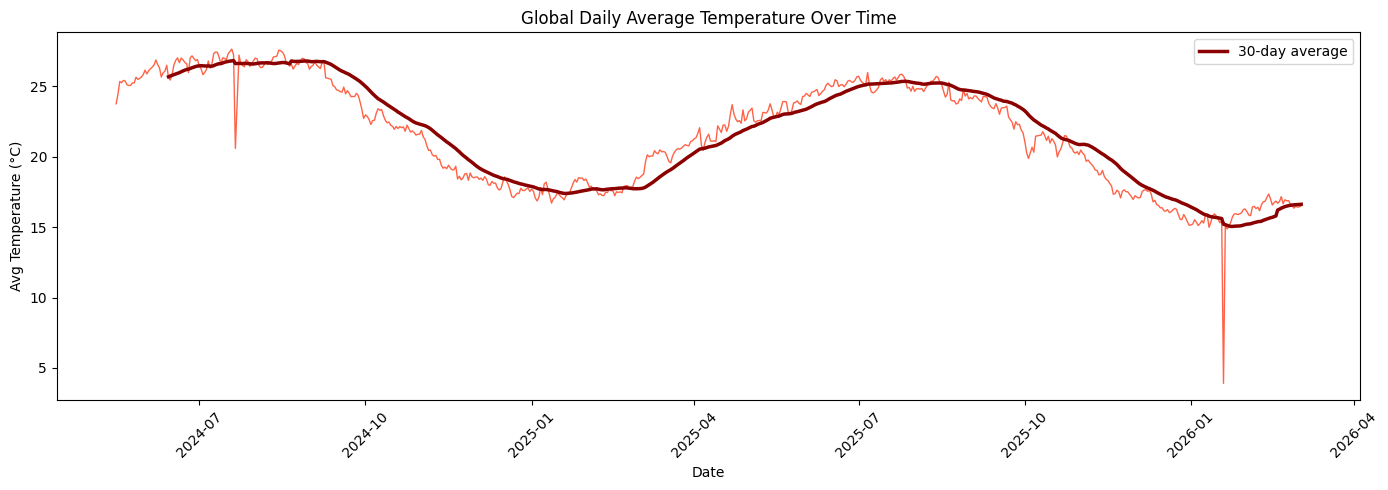

In [19]:

df["date"] = df["last_updated"].dt.date


daily_temp = (df.groupby("date")["temperature_celsius"]
              .mean()
              .reset_index())

plt.figure(figsize=(14, 5))
plt.plot(daily_temp["date"], daily_temp["temperature_celsius"],
         color="tomato", linewidth=1)


rolling = pd.Series(daily_temp["temperature_celsius"]).rolling(30).mean()
plt.plot(daily_temp["date"], rolling,
         color="darkred", linewidth=2.5, label="30-day average")

plt.title("Global Daily Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Temperature (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.ensemble import IsolationForest

iso_features = [
    "temperature_celsius", "humidity",
    "wind_kph", "pressure_mb", "precip_mm"
]

iso = IsolationForest(
    contamination=0.03,  # expect 3% anomalies
    random_state=42,
    n_jobs=-1
)

df["anomaly"] = iso.fit_predict(df[iso_features])

normal    = df[df["anomaly"] == 1]
anomalies = df[df["anomaly"] == -1]

print(f"Total readings:     {len(df):,}")
print(f"Normal readings:    {len(normal):,}")
print(f"Anomalies detected: {len(anomalies):,}")
print(f"Anomaly percentage: {len(anomalies)/len(df)*100:.2f}%")

Total readings:     127,451
Normal readings:    123,627
Anomalies detected: 3,824
Anomaly percentage: 3.00%


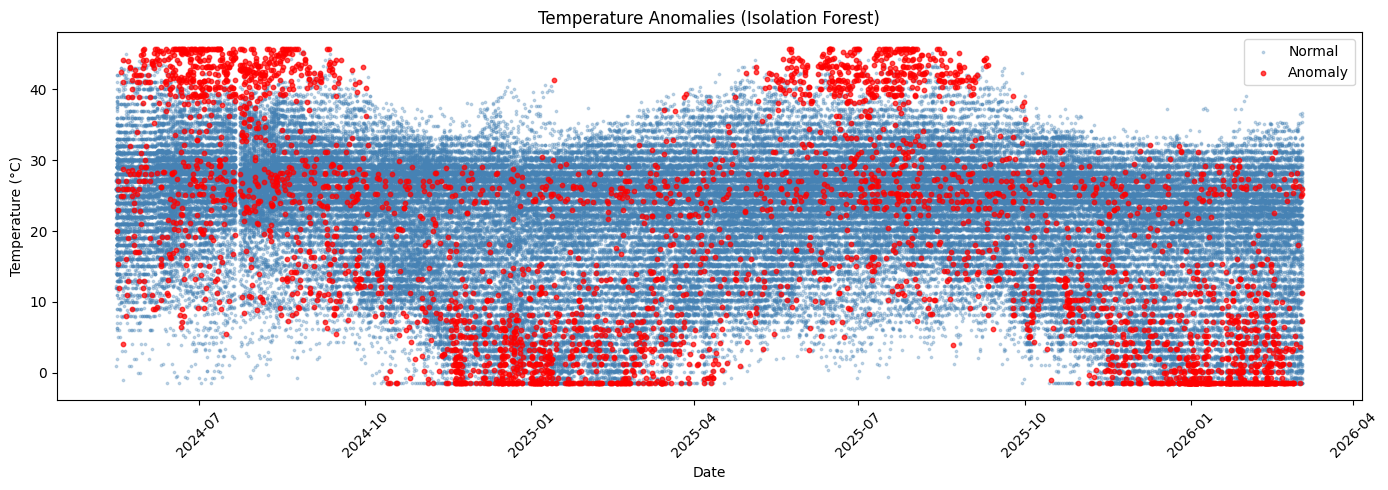


Top 5 periods with most anomalies:
 Period  Count
2026-01    302
2024-07    283
2025-07    265
2024-08    234
2024-06    221


In [21]:
plt.figure(figsize=(14, 5))

plt.scatter(normal["last_updated"], normal["temperature_celsius"],
            s=3, alpha=0.3, color="steelblue", label="Normal")

plt.scatter(anomalies["last_updated"], anomalies["temperature_celsius"],
            s=10, alpha=0.7, color="red", label="Anomaly")

plt.title("Temperature Anomalies (Isolation Forest)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find which periods have most anomalies
anomalies_copy = anomalies.copy()
anomalies_copy["month_year"] = anomalies_copy["last_updated"].dt.to_period("M")

anomaly_periods = (anomalies_copy.groupby("month_year")
                   .size()
                   .sort_values(ascending=False)
                   .head(5)
                   .reset_index())
anomaly_periods.columns = ["Period", "Count"]
print("\nTop 5 periods with most anomalies:")
print(anomaly_periods.to_string(index=False))

# BUILDING ML MODELS

In [22]:
feature_cols = [
    "humidity", "wind_kph", "pressure_mb", "precip_mm",
    "uv_index", "air_quality_PM2.5", "visibility_km",
    "month", "hour", "dayofweek", "year", "day",
    "latitude", "longitude"
]

TARGET = "temperature_celsius"

ml_df = df[feature_cols + [TARGET]].dropna()

X = ml_df[feature_cols]
y = ml_df[TARGET]

# Time based split — 80% train, 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Total rows:     {len(X):,}")
print(f"Training rows:  {len(X_train):,}")
print(f"Testing rows:   {len(X_test):,}")

Total rows:     127,451
Training rows:  101,960
Testing rows:   25,491


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=100,  # 100 decision trees
    max_depth=10,      # how deep each tree can go
    random_state=42,   # so results are reproducible
    n_jobs=-1          # use all CPU cores
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

mae  = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2   = r2_score(y_test, rf_preds)


print(f"\nMAE  : {mae:.3f} °C")
print(f"RMSE : {rmse:.3f} °C")
print(f"R²   : {r2:.4f}")


MAE  : 2.748 °C
RMSE : 3.746 °C
R²   : 0.8636


In [24]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200,    # 200 trees
    learning_rate=0.05,  # how fast it learns
    max_depth=6,         # tree depth
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2   = r2_score(y_test, xgb_preds)


print(f"\nMAE  : {mae:.3f} °C")
print(f"RMSE : {rmse:.3f} °C")
print(f"R²   : {r2:.4f}")


MAE  : 2.259 °C
RMSE : 3.050 °C
R²   : 0.9096


In [25]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor(
    estimators=[
        ("rf", rf),
        ("xgb", xgb_model)
    ],
    n_jobs=-1
)

ensemble.fit(X_train, y_train)
ens_preds = ensemble.predict(X_test)

mae  = mean_absolute_error(y_test, ens_preds)
rmse = np.sqrt(mean_squared_error(y_test, ens_preds))
r2   = r2_score(y_test, ens_preds)

print("Ensemble trained!")
print(f"\nMAE  : {mae:.3f} °C")
print(f"RMSE : {rmse:.3f} °C")
print(f"R²   : {r2:.4f}")

Ensemble trained!

MAE  : 2.421 °C
RMSE : 3.285 °C
R²   : 0.8951


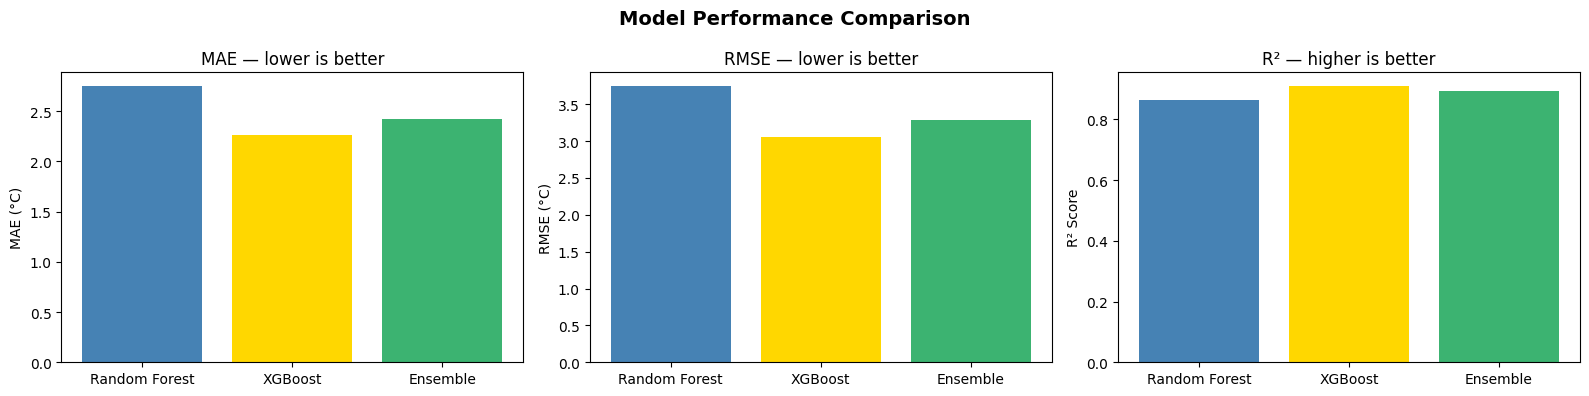

In [26]:
models     = ["Random Forest", "XGBoost", "Ensemble"]
mae_scores = [2.748, 2.259, 2.421]
rmse_scores= [3.746, 3.050, 3.285]
r2_scores  = [0.8636, 0.9096, 0.8951]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MAE chart
axes[0].bar(models, mae_scores,
            color=["steelblue", "gold", "mediumseagreen"])
axes[0].set_title("MAE — lower is better")
axes[0].set_ylabel("MAE (°C)")

# RMSE chart
axes[1].bar(models, rmse_scores,
            color=["steelblue", "gold", "mediumseagreen"])
axes[1].set_title("RMSE — lower is better")
axes[1].set_ylabel("RMSE (°C)")

# R² chart
axes[2].bar(models, r2_scores,
            color=["steelblue", "gold", "mediumseagreen"])
axes[2].set_title("R² — higher is better")
axes[2].set_ylabel("R² Score")

plt.suptitle("Model Performance Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# **Feature Importance**

/tmp/ipykernel_509/3995321097.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.index, y=feat_imp.values, palette="viridis")


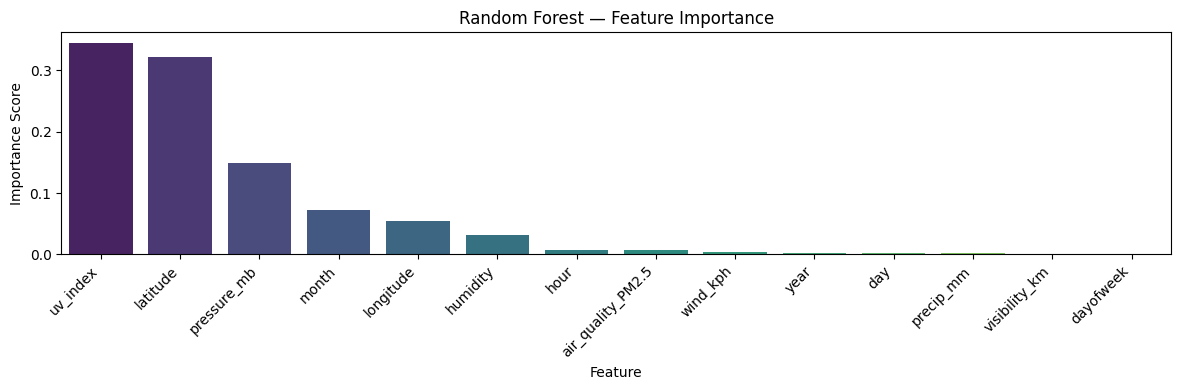


Calculating SHAP values...


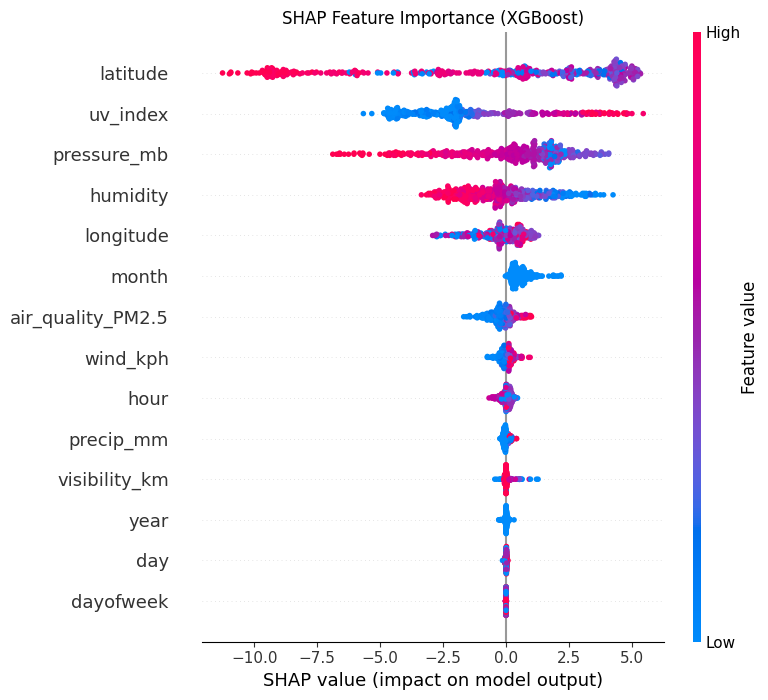

 Feature importance done!


In [34]:
import shap

# Random Forest importance
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(12, 4))
sns.barplot(x=feat_imp.index, y=feat_imp.values, palette="viridis")
plt.title("Random Forest — Feature Importance")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# SHAP values on XGBoost
print("\nCalculating SHAP values...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500], show=False)
plt.title("SHAP Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()
print(" Feature importance done!")

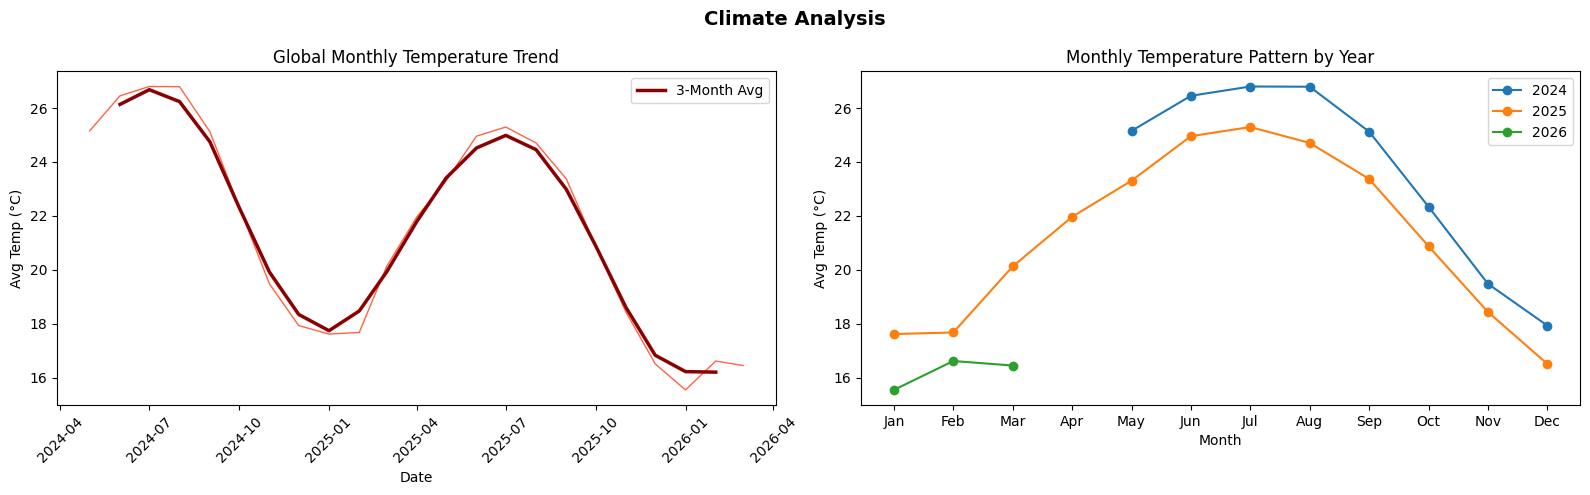

In [33]:
# Long term monthly temperature trend
monthly = df.groupby(["year", "month"])["temperature_celsius"].mean().reset_index()
monthly["ym"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global monthly trend
axes[0].plot(monthly["ym"], monthly["temperature_celsius"],
             color="tomato", linewidth=1)
rolling = monthly["temperature_celsius"].rolling(3, center=True).mean()
axes[0].plot(monthly["ym"], rolling,
             color="darkred", linewidth=2.5, label="3-Month Avg")
axes[0].set_title("Global Monthly Temperature Trend")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Avg Temp (°C)")
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Seasonal pattern per year
for year in df["year"].unique():
    yearly = df[df["year"] == year].groupby("month")["temperature_celsius"].mean()
    axes[1].plot(yearly.index, yearly.values, marker="o", label=str(year))
axes[1].set_title("Monthly Temperature Pattern by Year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Temp (°C)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[1].legend()

plt.suptitle("Climate Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

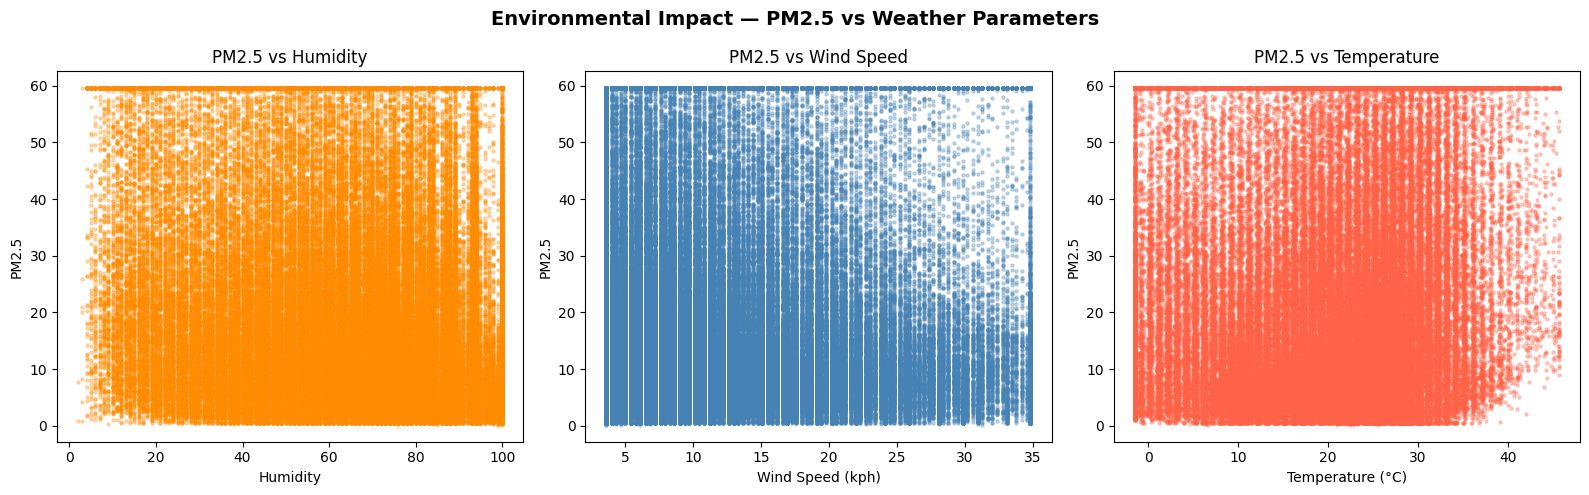

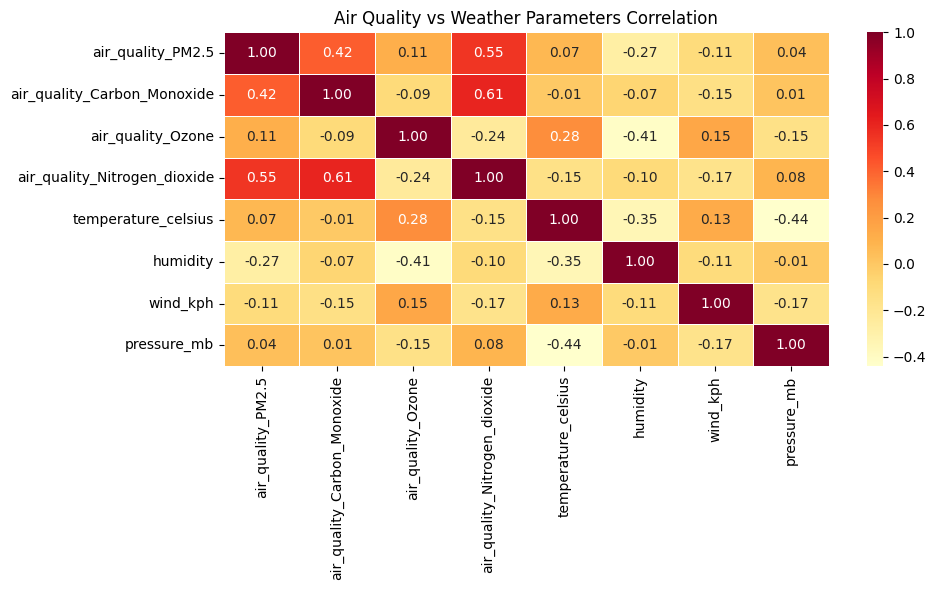

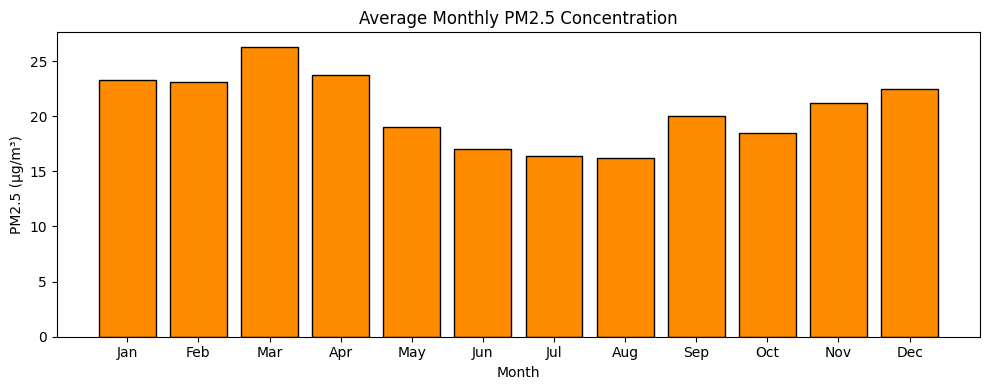

In [32]:
aq_cols = [
    "air_quality_PM2.5", "air_quality_Carbon_Monoxide",
    "air_quality_Ozone", "air_quality_Nitrogen_dioxide"
]

weather_cols = [
    "temperature_celsius", "humidity",
    "wind_kph", "pressure_mb"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PM2.5 vs Humidity
axes[0].scatter(df["humidity"], df["air_quality_PM2.5"],
                alpha=0.3, s=5, color="darkorange")
axes[0].set_xlabel("Humidity")
axes[0].set_ylabel("PM2.5")
axes[0].set_title("PM2.5 vs Humidity")

# PM2.5 vs Wind Speed
axes[1].scatter(df["wind_kph"], df["air_quality_PM2.5"],
                alpha=0.3, s=5, color="steelblue")
axes[1].set_xlabel("Wind Speed (kph)")
axes[1].set_ylabel("PM2.5")
axes[1].set_title("PM2.5 vs Wind Speed")

# PM2.5 vs Temperature
axes[2].scatter(df["temperature_celsius"], df["air_quality_PM2.5"],
                alpha=0.3, s=5, color="tomato")
axes[2].set_xlabel("Temperature (°C)")
axes[2].set_ylabel("PM2.5")
axes[2].set_title("PM2.5 vs Temperature")

plt.suptitle("Environmental Impact — PM2.5 vs Weather Parameters",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Air quality correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[aq_cols + weather_cols].corr(),
            annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5)
plt.title("Air Quality vs Weather Parameters Correlation")
plt.tight_layout()
plt.show()

# Monthly PM2.5 trend
monthly_pm = df.groupby("month")["air_quality_PM2.5"].mean()
plt.figure(figsize=(10, 4))
plt.bar(monthly_pm.index, monthly_pm.values,
        color="darkorange", edgecolor="black")
plt.title("Average Monthly PM2.5 Concentration")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()